# MKNN Alignment from HuggingFace embeddings

Runs Aristotelian MKNN analyses using only the embeddings on
`nitrox639/platonic-embeddings`:

1. **Intramodal** alignment within each EEG model (consecutive size pairs). reve is skipped.
2. **Cross-modal** EEG vs the matching VideoMAE embeddings (k=5, k=10).
3. **Cross-modal** EEG vs the matching DINOv2 embeddings (k=5, k=10).
4. **Cross-modal** EEG vs the matching V-JEPA 2 embeddings (k=5, k=10).
5. **Cross-modal** EEG vs the matching VideoMAE Kinetics-finetuned embeddings (k=5, k=10).

All embeddings are **layerwise**: EEG arrays are `(n_layers, W, S, D)` and the
vision arrays are `(n_layers, W, D)`. Every analysis searches over
*all* layer pairs (EEG layer i vs vision/EEG layer j), reports the maximum mKNN,
and calibrates that maximum against an aggregation-aware permutation null — the
protocol of Huh et al. 2024 / the Aristotelian-view paper.

All helpers, constants, and the generic cross-modal driver `run_cross_modal(...)`
live in the setup cell. Subsequent cells just call `run_cross_modal(..., k_mknn)`
and plot the results.

In [1]:
from pathlib import Path
import os, json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from huggingface_hub import hf_hub_download

# ── Auth ──────────────────────────────────────────────────────────────────────
REPO = 'nitrox639/platonic-embeddings'
for _tp in (Path('../tokens/hf_token.txt'), Path('tokens/hf_token.txt'),
            Path('hf_token.txt'), Path.home() / 'hf_token.txt'):
    if _tp.exists():
        os.environ['HF_TOKEN'] = _tp.read_text().strip()
        break

def fetch(p):
    return hf_hub_download(REPO, p, repo_type='dataset')

def load_npz(p):
    return np.load(fetch(p), allow_pickle=True)

# ── Model registry ────────────────────────────────────────────────────────────
EEG = {
    'femba':       {'sizes': ['tiny', 'base', 'large'],  'family': 'femba_luna',
                    'fname': lambda s: f'eeg/femba/femba_{s}_tusl_layerwise.npz'},
    'luna':        {'sizes': ['base', 'large', 'huge'],  'family': 'femba_luna',
                    'fname': lambda s: f'eeg/luna/luna_{s}_layerwise.npz'},
    'neurolm':     {'sizes': ['b', 'l', 'xl'],           'family': 'neurolm',
                    'fname': lambda s: f'eeg/neurolm/neurolm_{s}_layerwise.npz'},
    'reve':        {'sizes': ['base', 'large'],          'family': 'reve',
                    'fname': lambda s: f'eeg/reve/reve_{s}_layerwise.npz'},
    'steegformer': {'sizes': ['small', 'base', 'large'], 'family': 'steegformer',
                    'fname': lambda s: f'eeg/steegformer/steegformer_{s}_layerwise.npz'},
}
VIDEOMAE_SIZES    = ['base', 'large']
VIDEOMAE_FT_SIZES = ['base', 'large', 'huge']
DINOV2_SIZES      = ['small', 'base', 'large', 'giant']
VJEPA2_SIZES      = ['large', 'huge', 'giant']

def vmpath(vs, fam):   return f'vision/videomae/videomae_{vs}__{fam}.npz'
def vmftpath(vs, fam): return f'vision/videomae_finetuned/videomae_ft_kinetics_{vs}__{fam}.npz'
def dnpath(vs, fam):   return f'vision/dinov2/dinov2_{vs}__{fam}.npz'
def vj2path(vs, fam):  return f'vision/vjepa2/vjepa2_{vs}__{fam}.npz'

# ── Display metadata ──────────────────────────────────────────────────────────
PARAMS = {
    'femba':       {'tiny': 8,   'base': 48,  'large': 78},
    'luna':        {'base': 7,   'large': 43, 'huge': 311},
    'neurolm':     {'b': 254,    'l': 500,    'xl': 1696},
    'steegformer': {'small': 22, 'base': 86,  'large': 307},
    'reve':        {'base': 69,  'large': 408},
}
DISPLAY = {'femba': 'FEMBA', 'luna': 'LUNA', 'neurolm': 'NeuroLM',
           'steegformer': 'STEEGFormer', 'reve': 'REVE'}
def fmt_size(model, sz): return f'{sz} ({PARAMS[model][sz]}M)'

vm_colors   = {'base': 'steelblue', 'large': 'seagreen'}
vmft_colors = {'base': 'firebrick', 'large': 'darkorchid', 'huge': 'darkorange'}
dn_colors   = {'small': 'steelblue', 'base': 'seagreen',
               'large': 'darkorange', 'giant': 'mediumpurple'}
vj2_colors  = {'large': 'steelblue', 'huge': 'seagreen', 'giant': 'darkorange'}

# ── Hyperparameters (mirror analyze_mknn.ipynb) ───────────────────────────────
K_MKNN = 5
K_PERM = 200
ALPHA  = 0.05

# ── kNN / mKNN primitives ─────────────────────────────────────────────────────
def l2(x):
    return x / (np.linalg.norm(x, axis=-1, keepdims=True) + 1e-12)

def knn_1d(z, k):
    nn = NearestNeighbors(n_neighbors=k+1, metric='cosine', algorithm='brute').fit(z)
    _, idx = nn.kneighbors(z)
    return idx[:, 1:].astype(np.int32)

def mknn_1d(ia, ib):
    return float((ia[:, :, None] == ib[:, None, :]).any(-1).mean())

def precompute_knn(emb, k):
    """Layerwise EEG: emb (n_layers, W, S, D) -> (n_layers, S, W, k)."""
    n_layers, W, Ns, _ = emb.shape
    idx = np.zeros((n_layers, Ns, W, k), dtype=np.int32)
    for l in range(n_layers):
        for s in range(Ns):
            idx[l, s] = knn_1d(l2(emb[l, :, s, :]), k)
    return idx

def precompute_knn_layers(emb, k):
    """Layerwise vision: emb (n_layers, W, D) -> (n_layers, W, k).
    A stale 2-D (W, D) array is promoted to a single layer for back-compat."""
    emb = np.asarray(emb)
    if emb.ndim == 2:
        emb = emb[None]
    n_layers, W, _ = emb.shape
    idx = np.zeros((n_layers, W, k), dtype=np.int32)
    for l in range(n_layers):
        idx[l] = knn_1d(l2(emb[l]), k)
    return idx

# ── Aristotelian MKNN ─────────────────────────────────────────────────────────
def _calibrate(T_obs, T_null, alpha):
    tau   = float(np.quantile(T_null, 1 - alpha))
    s_cal = max(T_obs - tau, 0.0) / (1 - tau) if tau < 1 else 0.0
    p_val = float((1 + (T_null >= T_obs).sum()) / (len(T_null) + 1))
    return tau, s_cal, p_val

def aristotelian_intra_subj(nn_a, nn_b, s, K=K_PERM, alpha=ALPHA, seed=42):
    """Intramodal, one subject. Searches all EEG-layer x EEG-layer pairs.
    nn_a, nn_b: (n_layers, S, W, k)."""
    LA, _, W, _ = nn_a.shape; LB = nn_b.shape[0]
    rng = np.random.default_rng(seed)
    a_s = nn_a[:, s]; b_s = nn_b[:, s]
    S_obs = np.array([[mknn_1d(a_s[la], b_s[lb]) for lb in range(LB)] for la in range(LA)])
    T_obs = float(S_obs.max())
    T_null = np.zeros(K)
    for ki in range(K):
        perm = rng.permutation(W); inv = np.argsort(perm)
        b_perm = inv[b_s[:, perm, :]]
        T_null[ki] = max(mknn_1d(a_s[la], b_perm[lb]) for la in range(LA) for lb in range(LB))
    tau, s_cal, p_val = _calibrate(T_obs, T_null, alpha)
    return T_obs, s_cal, tau, p_val

def aristotelian_cross(nn_eeg_layers, nn_vis_layers, K=K_PERM, alpha=ALPHA, seed=42):
    """Cross-modal, one subject. Searches all EEG-layer x vision-layer pairs.
    nn_eeg_layers: (LE, W, k)   nn_vis_layers: (LV, W, k)."""
    LE, W, _ = nn_eeg_layers.shape
    LV = nn_vis_layers.shape[0]
    rng = np.random.default_rng(seed)
    S_obs = np.array([[mknn_1d(nn_eeg_layers[le], nn_vis_layers[lv]) for lv in range(LV)]
                      for le in range(LE)])
    T_obs = float(S_obs.max())
    T_null = np.zeros(K)
    for ki in range(K):
        perm = rng.permutation(W); inv = np.argsort(perm)
        v_perm = inv[nn_vis_layers[:, perm, :]]            # (LV, W, k)
        T_null[ki] = max(mknn_1d(nn_eeg_layers[le], v_perm[lv])
                         for le in range(LE) for lv in range(LV))
    tau, s_cal, p_val = _calibrate(T_obs, T_null, alpha)
    return T_obs, s_cal, tau, p_val

# ── Generic cross-modal driver (used by all cross-modal compute cells) ────────
def run_cross_modal(eeg_model, vision_arch, vision_sizes, vfname, k_mknn):
    fam       = EEG[eeg_model]['family']
    eeg_sizes = EEG[eeg_model]['sizes']
    vis_nn = {}
    for vs in vision_sizes:
        vemb = load_npz(vfname(vs, fam))['embeddings'].astype(np.float32)
        print(f'  {vision_arch}-{vs} ({fam}): {vemb.shape}')
        vis_nn[vs] = precompute_knn_layers(vemb, k_mknn)   # (LV, W, k)
    results = {}
    for esz in eeg_sizes:
        emb = load_npz(EEG[eeg_model]['fname'](esz))['embeddings'].astype(np.float32)
        n_layers, W, S, _ = emb.shape
        print(f'  {eeg_model}-{esz}: {emb.shape}  precomputing EEG kNN...')
        nn_eeg = precompute_knn(emb, k_mknn)               # (n_layers, S, W, k)
        for vs in vision_sizes:
            LV = vis_nn[vs].shape[0]
            print(f'    cross  {eeg_model}-{esz} ({n_layers}L)  x  '
                  f'{vision_arch}-{vs} ({LV}L)  = {n_layers*LV} layer pairs')
            T_l, sc_l, tau_l, p_l = [], [], [], []
            for s in range(S):
                T, sc, tau, p = aristotelian_cross(
                    nn_eeg[:, s], vis_nn[vs], K=K_PERM, alpha=ALPHA, seed=42+s)
                T_l.append(T); sc_l.append(sc); tau_l.append(tau); p_l.append(p)
                print(f'      sub-{s+1:04d}: uncal={T:.4f}  tau={tau:.4f}  cal={sc:.4f}  p={p:.4f}')
            results[(esz, vs)] = dict(
                T_obs=np.array(T_l), s_cal=np.array(sc_l),
                tau=np.array(tau_l), p=np.array(p_l))
    return results

print('Setup complete. EEG models:', list(EEG.keys()))

C:\tools\Manim\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete. EEG models: ['femba', 'luna', 'neurolm', 'reve', 'steegformer']


In [2]:
from scipy.stats import ttest_rel

def _sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def _bracket_label(arr1, arr2, S_n):
    """Paired t-test + direction count for two (S,) arrays."""
    _, pval = ttest_rel(arr1, arr2)
    n_up = int((arr2 > arr1).sum())
    return f"{_sig_stars(pval)} ({n_up}/{S_n}↑)", pval

def plot_cross_modal(results, eeg_models, vision_sizes, vis_colors, arch_name, k, k_perm,
                     params=None, display=None):
    """x = EEG sizes, one colored line per vision size.
    - Colored text between consecutive x-points: EEG-scaling p-value (color matches line).
    - Yellow box above each x-position: vision-scaling p-values for that EEG size.
    First/last boxes are left/right-aligned to stay inside the axes.
    """
    if params  is None: params  = PARAMS
    if display is None: display = DISPLAY
    models = list(eeg_models.keys())
    ncols = 3
    nrows = (len(models) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.8, nrows * 5.4))
    axes_flat = axes.flatten()

    for ax, model in zip(axes_flat, models):
        eeg_sizes = eeg_models[model]['sizes']
        x = np.arange(len(eeg_sizes))
        S_n = len(results[model][(eeg_sizes[0], vision_sizes[0])]['s_cal'])

        cal_mats = {vs: np.array([[results[model][(esz, vs)]['s_cal'][s]
                                   for esz in eeg_sizes] for s in range(S_n)])
                    for vs in vision_sizes}
        means = {vs: cal_mats[vs].mean(0) for vs in vision_sizes}
        stds  = {vs: cal_mats[vs].std(0)  for vs in vision_sizes}

        for vs in vision_sizes:
            ax.errorbar(x, means[vs], yerr=stds[vs], color=vis_colors[vs],
                        lw=2.5, marker='o', markersize=7, capsize=4,
                        label=f'{arch_name}-{vs}')

        all_top = max((means[vs] + stds[vs]).max() for vs in vision_sizes)
        all_bot = min((means[vs] - stds[vs]).min() for vs in vision_sizes)
        data_range = max(all_top - all_bot, 1e-6)

        # ── EEG scaling: colored text between consecutive x-points, on each line ──
        for xi in range(len(eeg_sizes) - 1):
            mid_x = xi + 0.5
            for vs in vision_sizes:
                label, _ = _bracket_label(cal_mats[vs][:, xi], cal_mats[vs][:, xi + 1], S_n)
                mid_y = (means[vs][xi] + means[vs][xi + 1]) / 2
                ax.text(mid_x, mid_y, label,
                        ha='center', va='center', fontsize=6.5,
                        color=vis_colors[vs], fontweight='bold',
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1.2))

        # ── Vision scaling: yellow box above each x-position ──────────────────
        v_pairs  = list(zip(vision_sizes[:-1], vision_sizes[1:]))
        box_base = all_top + data_range * 0.10
        last_xi  = len(eeg_sizes) - 1

        for xi in range(len(eeg_sizes)):
            lines = []
            for v1, v2 in v_pairs:
                label, _ = _bracket_label(cal_mats[v1][:, xi], cal_mats[v2][:, xi], S_n)
                lines.append(f'{v1}→{v2}: {label}')
            ha = 'left' if xi == 0 else ('right' if xi == last_xi else 'center')
            ax.text(xi, box_base, '\n'.join(lines),
                    ha=ha, va='bottom', fontsize=5.5, linespacing=1.4,
                    bbox=dict(boxstyle='round,pad=0.35', facecolor='lightyellow',
                              edgecolor='dimgray', alpha=0.9))

        y_top = box_base + data_range * 0.22 * len(v_pairs)
        pad   = (y_top - all_bot) * 0.04
        ax.set_ylim(bottom=all_bot - pad, top=y_top + pad)

        xtick_labels = [f'{sz}\n({params[model][sz]}M)' for sz in eeg_sizes]
        ax.set_xticks(x); ax.set_xticklabels(xtick_labels, fontsize=9)
        ax.set_xlabel(f'{display[model]} size')
        ax.set_ylabel('mKNN score (calibrated)', fontsize=10)
        ax.set_title(display[model], fontsize=13, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        ax.legend(fontsize=7)

    for i in range(len(models), len(axes_flat)):
        axes_flat[i].set_visible(False)

    fig.suptitle(
        f'Cross-modal MKNN — EEG vs {arch_name}  (k={k}, K_perm={k_perm})\n'
        'mean ± std across subjects   |   colored text: EEG-scaling significance   |   '
        'yellow boxes: vision-scaling significance\n'
        '* p<.05  ** p<.01  *** p<.001  (n/N↑ = subjects with increase)',
        fontsize=9)
    plt.tight_layout()
    plt.show()


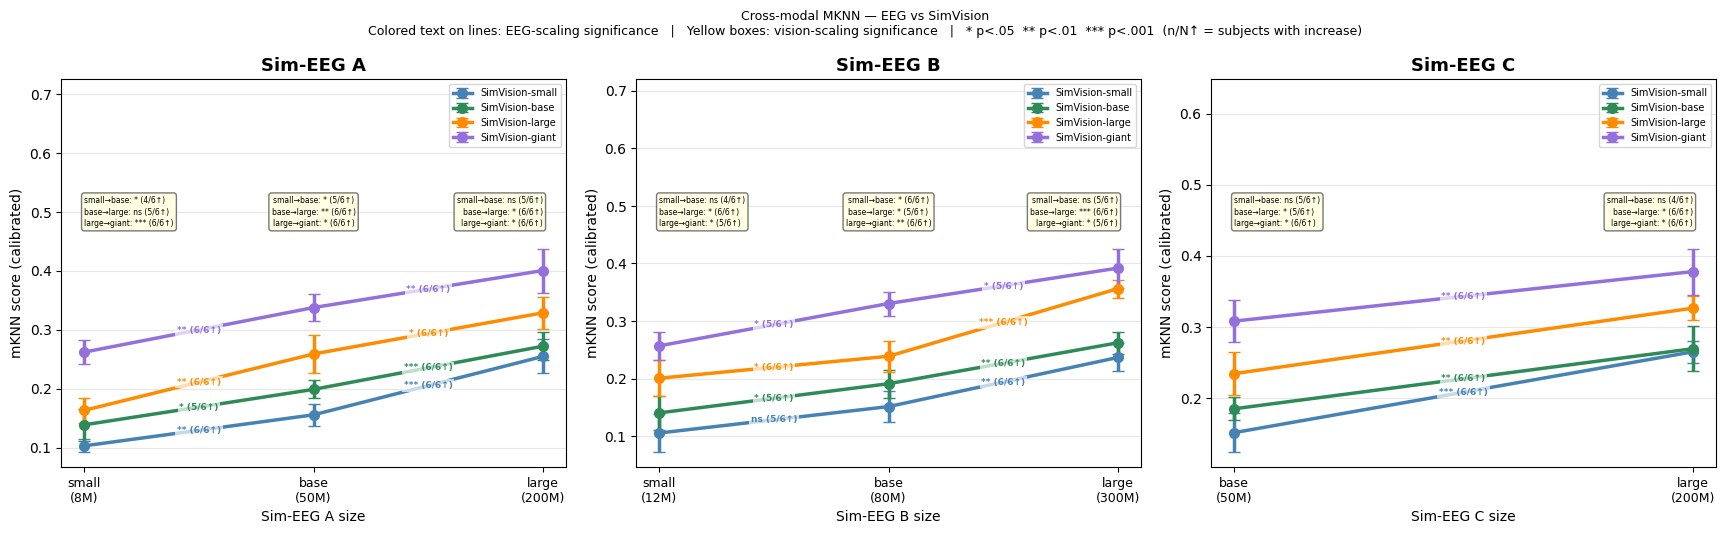

In [3]:
# ── Quick visual test — simulated data, runs instantly ────────────────────────
_rng = np.random.default_rng(0)
_S = 6

_eeg_t = {
    'modA': {'sizes': ['small', 'base', 'large'], 'family': 'x'},
    'modB': {'sizes': ['small', 'base', 'large'], 'family': 'x'},
    'modC': {'sizes': ['base', 'large'],          'family': 'x'},
}
PARAMS.update({
    'modA': {'small': 8,  'base': 50,  'large': 200},
    'modB': {'small': 12, 'base': 80,  'large': 300},
    'modC': {'base': 50,  'large': 200},
})
DISPLAY.update({'modA': 'Sim-EEG A', 'modB': 'Sim-EEG B', 'modC': 'Sim-EEG C'})

_vis_sizes_t  = ['small', 'base', 'large', 'giant']
_vis_colors_t = {'small': 'steelblue', 'base': 'seagreen',
                 'large': 'darkorange', 'giant': 'mediumpurple'}

_eeg_bump = {'small': 0.00, 'base': 0.06, 'large': 0.14}
_vis_bump  = {'small': 0.00, 'base': 0.04, 'large': 0.09, 'giant': 0.15}

_results_t = {}
for _m in _eeg_t:
    _results_t[_m] = {}
    for _esz in _eeg_t[_m]['sizes']:
        for _vs in _vis_sizes_t:
            _mu = 0.10 + _eeg_bump[_esz] + _vis_bump[_vs]
            _scores = np.clip(_rng.normal(_mu, 0.03, _S), 0, 1)
            _results_t[_m][(_esz, _vs)] = {'s_cal': _scores}


def _plot_demo(results, eeg_models, vision_sizes, vis_colors, arch_name, params, display):
    """Single combined plot.
    - x = EEG sizes, one colored line per vision size (as before).
    - Colored text between consecutive x-points: EEG-scaling p-value (color matches line).
    - Yellow box above each x-position: vision-scaling p-values for that EEG size.
    """
    models = list(eeg_models.keys())
    ncols = 3
    nrows = (len(models) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.8, nrows * 5.4))
    axes_flat = axes.flatten()

    for ax, model in zip(axes_flat, models):
        eeg_sizes = eeg_models[model]['sizes']
        x = np.arange(len(eeg_sizes))
        S_n = len(results[model][(eeg_sizes[0], vision_sizes[0])]['s_cal'])

        cal_mats = {vs: np.array([[results[model][(esz, vs)]['s_cal'][s]
                                   for esz in eeg_sizes] for s in range(S_n)])
                    for vs in vision_sizes}
        means = {vs: cal_mats[vs].mean(0) for vs in vision_sizes}
        stds  = {vs: cal_mats[vs].std(0)  for vs in vision_sizes}

        for vs in vision_sizes:
            ax.errorbar(x, means[vs], yerr=stds[vs], color=vis_colors[vs],
                        lw=2.5, marker='o', markersize=7, capsize=4,
                        label=f'{arch_name}-{vs}')

        all_top = max((means[vs] + stds[vs]).max() for vs in vision_sizes)
        all_bot = min((means[vs] - stds[vs]).min() for vs in vision_sizes)
        data_range = max(all_top - all_bot, 1e-6)

        # ── EEG scaling: colored text between consecutive x-points, on each line ──
        for xi in range(len(eeg_sizes) - 1):
            mid_x = xi + 0.5
            for vs in vision_sizes:
                label, _ = _bracket_label(cal_mats[vs][:, xi], cal_mats[vs][:, xi + 1], S_n)
                mid_y = (means[vs][xi] + means[vs][xi + 1]) / 2
                ax.text(mid_x, mid_y, label,
                        ha='center', va='center', fontsize=6.5,
                        color=vis_colors[vs], fontweight='bold',
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1.2))

        # ── Vision scaling: yellow box above each x-position ──────────────────
        v_pairs  = list(zip(vision_sizes[:-1], vision_sizes[1:]))
        box_base = all_top + data_range * 0.10
        last_xi  = len(eeg_sizes) - 1

        for xi in range(len(eeg_sizes)):
            lines = []
            for v1, v2 in v_pairs:
                label, _ = _bracket_label(cal_mats[v1][:, xi], cal_mats[v2][:, xi], S_n)
                lines.append(f'{v1}→{v2}: {label}')
            # Left-align first box, right-align last, center the rest
            ha = 'left' if xi == 0 else ('right' if xi == last_xi else 'center')
            ax.text(xi, box_base, '\n'.join(lines),
                    ha=ha, va='bottom', fontsize=5.5, linespacing=1.4,
                    bbox=dict(boxstyle='round,pad=0.35', facecolor='lightyellow',
                              edgecolor='dimgray', alpha=0.9))

        y_top = box_base + data_range * 0.22 * len(v_pairs)
        pad   = (y_top - all_bot) * 0.04
        ax.set_ylim(bottom=all_bot - pad, top=y_top + pad)

        xtick_labels = [f'{sz}\n({params[model][sz]}M)' for sz in eeg_sizes]
        ax.set_xticks(x); ax.set_xticklabels(xtick_labels, fontsize=9)
        ax.set_xlabel(f'{display[model]} size')
        ax.set_ylabel('mKNN score (calibrated)', fontsize=10)
        ax.set_title(display[model], fontsize=13, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        ax.legend(fontsize=7)

    for i in range(len(models), len(axes_flat)):
        axes_flat[i].set_visible(False)

    fig.suptitle(
        f'Cross-modal MKNN — EEG vs {arch_name}\n'
        'Colored text on lines: EEG-scaling significance   |   '
        'Yellow boxes: vision-scaling significance   |   '
        '* p<.05  ** p<.01  *** p<.001  (n/N↑ = subjects with increase)',
        fontsize=9)
    plt.tight_layout()
    plt.show()


_plot_demo(_results_t, _eeg_t, _vis_sizes_t, _vis_colors_t,
           'SimVision', PARAMS, DISPLAY)

# Clean up
for _k in list(_eeg_t.keys()):
    PARAMS.pop(_k, None); DISPLAY.pop(_k, None)
del _rng, _S, _eeg_t, _vis_sizes_t, _vis_colors_t, _eeg_bump, _vis_bump, _results_t, _k


## 1. Intramodal alignment per EEG model

For each EEG model (excluding reve): Aristotelian MKNN over **consecutive size pairs**.
Errorbars show mean ± std across subjects (calibrated scores only).

In [3]:
INTRA_MODELS = [m for m in EEG if m != 'reve']

intra_results = {}   # intra_results[model] = {(a,b): {'T_obs','s_cal','tau','p'}}

for model in INTRA_MODELS:
    sizes = EEG[model]['sizes']
    pairs = list(zip(sizes[:-1], sizes[1:]))
    print(f'\n=== {model}  sizes={sizes}  pairs={pairs} ===')
    nn_by_size = {}
    for sz in sizes:
        emb = load_npz(EEG[model]['fname'](sz))['embeddings'].astype(np.float32)
        print(f'  loading {model}-{sz}: {emb.shape}')
        nn_by_size[sz] = precompute_knn(emb, K_MKNN)
    S = next(iter(nn_by_size.values())).shape[1]
    intra_results[model] = {}
    for (a, b) in pairs:
        print(f'  pair {a}<->{b} ({nn_by_size[a].shape[0]}x{nn_by_size[b].shape[0]} layer pairs)')
        T_l, sc_l, tau_l, p_l = [], [], [], []
        for s in range(S):
            T, sc, tau, p = aristotelian_intra_subj(
                nn_by_size[a], nn_by_size[b], s, K=K_PERM, alpha=ALPHA, seed=42+s)
            T_l.append(T); sc_l.append(sc); tau_l.append(tau); p_l.append(p)
            print(f'    sub-{s+1:04d}: uncal={T:.4f}  tau={tau:.4f}  cal={sc:.4f}  p={p:.4f}')
        intra_results[model][(a, b)] = dict(
            T_obs=np.array(T_l), s_cal=np.array(sc_l),
            tau=np.array(tau_l), p=np.array(p_l))



=== femba  sizes=['tiny', 'base', 'large']  pairs=[('tiny', 'base'), ('base', 'large')] ===
  loading femba-tiny: (2, 2160, 6, 385)
  loading femba-base: (12, 2160, 6, 385)
  loading femba-large: (4, 2160, 6, 869)
  pair tiny<->base (2x12 layer pairs)
    sub-0001: uncal=0.1964  tau=0.0038  cal=0.1933  p=0.0050
    sub-0002: uncal=0.1817  tau=0.0039  cal=0.1785  p=0.0050
    sub-0003: uncal=0.1403  tau=0.0037  cal=0.1371  p=0.0050
    sub-0004: uncal=0.1245  tau=0.0039  cal=0.1211  p=0.0050
    sub-0005: uncal=0.1529  tau=0.0039  cal=0.1496  p=0.0050
    sub-0006: uncal=0.1575  tau=0.0038  cal=0.1543  p=0.0050
  pair base<->large (12x4 layer pairs)
    sub-0001: uncal=0.5845  tau=0.0039  cal=0.5829  p=0.0050
    sub-0002: uncal=0.4686  tau=0.0039  cal=0.4665  p=0.0050
    sub-0003: uncal=0.5618  tau=0.0039  cal=0.5600  p=0.0050
    sub-0004: uncal=0.4692  tau=0.0040  cal=0.4670  p=0.0050
    sub-0005: uncal=0.4428  tau=0.0040  cal=0.4406  p=0.0050
    sub-0006: uncal=0.3939  tau=0.003

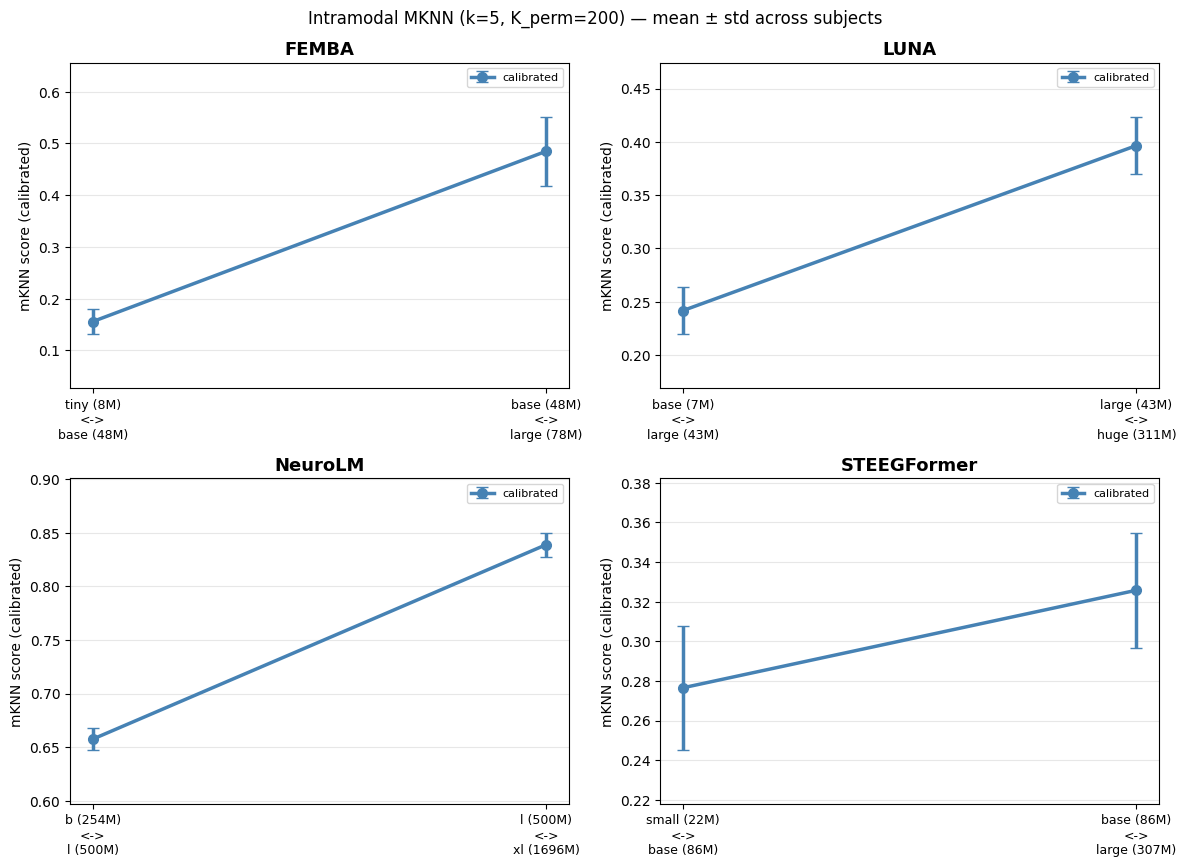

In [4]:
ncols = 2
nrows = (len(INTRA_MODELS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 4.4))
axes_flat = axes.flatten()

for ax, model in zip(axes_flat, INTRA_MODELS):
    pairs = list(intra_results[model].keys())
    pair_labels = [f'{fmt_size(model, a)}\n<->\n{fmt_size(model, b)}' for (a, b) in pairs]
    x = np.arange(len(pairs))
    S = len(intra_results[model][pairs[0]]['s_cal'])
    cal_mat = np.array([[intra_results[model][p]['s_cal'][s] for p in pairs] for s in range(S)])
    means = cal_mat.mean(0)
    stds  = cal_mat.std(0)

    ax.errorbar(x, means, yerr=stds, color='steelblue', lw=2.5,
                marker='o', markersize=7, capsize=4, label='calibrated')

    y_lo = (means - stds).min()
    y_hi = (means + stds).max()
    pad  = max((y_hi - y_lo) * 0.25, 0.005)
    ax.set_ylim(bottom=y_lo - pad, top=y_hi + pad)

    ax.set_xticks(x); ax.set_xticklabels(pair_labels, fontsize=9)
    ax.set_ylabel('mKNN score (calibrated)', fontsize=10)
    ax.set_title(DISPLAY[model], fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)

for i in range(len(INTRA_MODELS), len(axes_flat)):
    axes_flat[i].set_visible(False)

fig.suptitle(f'Intramodal MKNN (k={K_MKNN}, K_perm={K_PERM}) — mean ± std across subjects',
             fontsize=12)
plt.tight_layout()
plt.show()

## 2. Cross-modal alignment: EEG vs corresponding VideoMAE

One subplot per EEG model (all 5 incl. reve). x = EEG sizes, one colored line per VideoMAE size.
Errorbars = std across subjects (calibrated scores only). Significance brackets show paired
t-tests between consecutive VideoMAE sizes at each EEG size.

In [15]:
cross_vm = {}
for model in EEG:
    print(f'\n=== cross-modal {model} vs VideoMAE  (k={K_MKNN}) ===')
    cross_vm[model] = run_cross_modal(model, 'videomae', VIDEOMAE_SIZES, vmpath, K_MKNN)



=== cross-modal femba vs VideoMAE  (k=5) ===
  videomae-base (femba_luna): (12, 2160, 768)
  videomae-large (femba_luna): (24, 2160, 1024)
  femba-tiny: (2, 2160, 6, 385)  precomputing EEG kNN...
    cross  femba-tiny (2L)  x  videomae-base (12L)  = 24 layer pairs
      sub-0001: uncal=0.0362  tau=0.0038  cal=0.0325  p=0.0050
      sub-0002: uncal=0.0269  tau=0.0037  cal=0.0233  p=0.0050
      sub-0003: uncal=0.0307  tau=0.0038  cal=0.0270  p=0.0050
      sub-0004: uncal=0.0231  tau=0.0039  cal=0.0193  p=0.0050
      sub-0005: uncal=0.0301  tau=0.0038  cal=0.0264  p=0.0050
      sub-0006: uncal=0.0284  tau=0.0039  cal=0.0246  p=0.0050
    cross  femba-tiny (2L)  x  videomae-large (24L)  = 48 layer pairs
      sub-0001: uncal=0.0375  tau=0.0039  cal=0.0337  p=0.0050
      sub-0002: uncal=0.0274  tau=0.0039  cal=0.0236  p=0.0050
      sub-0003: uncal=0.0335  tau=0.0039  cal=0.0297  p=0.0050
      sub-0004: uncal=0.0230  tau=0.0039  cal=0.0191  p=0.0050
      sub-0005: uncal=0.0319  tau=

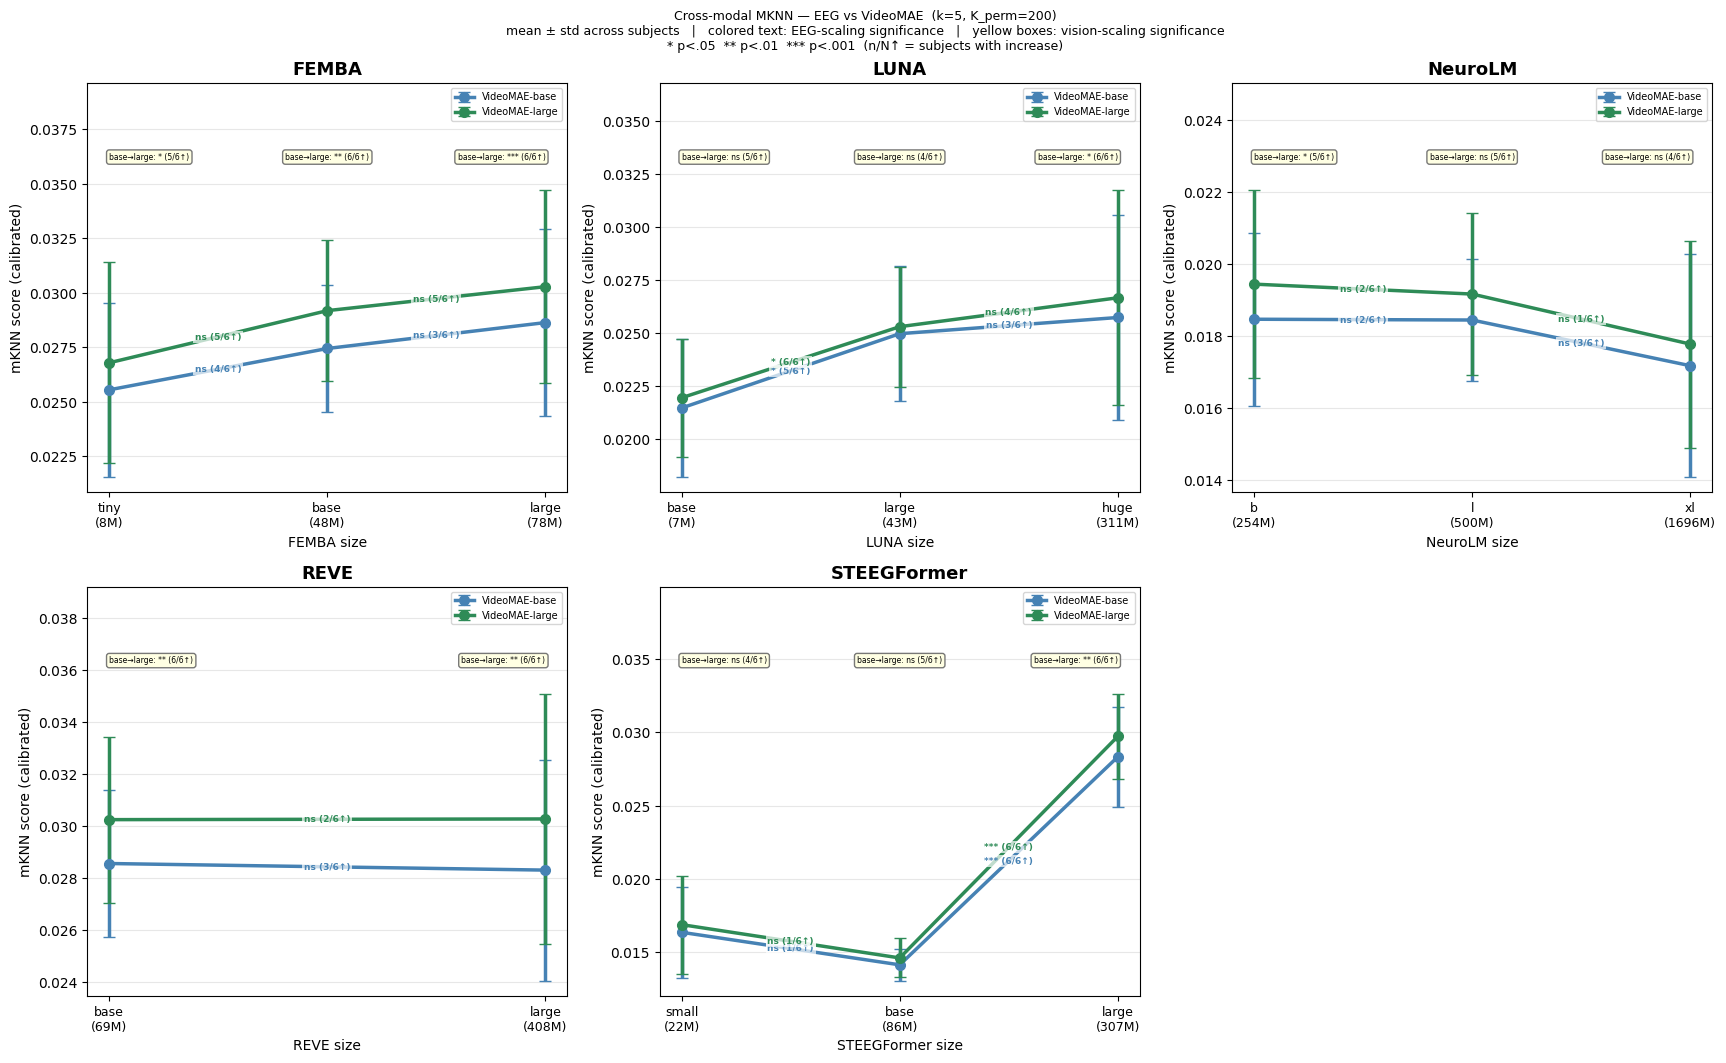

In [16]:
plot_cross_modal(cross_vm, EEG, VIDEOMAE_SIZES, vm_colors, 'VideoMAE', K_MKNN, K_PERM)


## 3. Cross-modal alignment: EEG vs corresponding DINOv2

Same structure as section 2, with DINOv2 (4 sizes). Errorbars = std across subjects
(calibrated only). Brackets show paired t-tests between consecutive DINOv2 sizes.

In [17]:
cross_dn = {}
for model in EEG:
    print(f'\n=== cross-modal {model} vs DINOv2  (k={K_MKNN}) ===')
    cross_dn[model] = run_cross_modal(model, 'dinov2', DINOV2_SIZES, dnpath, K_MKNN)



=== cross-modal femba vs DINOv2  (k=5) ===
  dinov2-small (femba_luna): (12, 2160, 384)
  dinov2-base (femba_luna): (12, 2160, 768)
  dinov2-large (femba_luna): (24, 2160, 1024)
  dinov2-giant (femba_luna): (40, 2160, 1536)
  femba-tiny: (2, 2160, 6, 385)  precomputing EEG kNN...
    cross  femba-tiny (2L)  x  dinov2-small (12L)  = 24 layer pairs
      sub-0001: uncal=0.0580  tau=0.0038  cal=0.0544  p=0.0050
      sub-0002: uncal=0.0424  tau=0.0039  cal=0.0387  p=0.0050
      sub-0003: uncal=0.0468  tau=0.0038  cal=0.0431  p=0.0050
      sub-0004: uncal=0.0354  tau=0.0039  cal=0.0316  p=0.0050
      sub-0005: uncal=0.0483  tau=0.0039  cal=0.0446  p=0.0050
      sub-0006: uncal=0.0429  tau=0.0039  cal=0.0391  p=0.0050
    cross  femba-tiny (2L)  x  dinov2-base (12L)  = 24 layer pairs
      sub-0001: uncal=0.0578  tau=0.0038  cal=0.0542  p=0.0050
      sub-0002: uncal=0.0425  tau=0.0039  cal=0.0388  p=0.0050
      sub-0003: uncal=0.0469  tau=0.0038  cal=0.0432  p=0.0050
      sub-0004: 

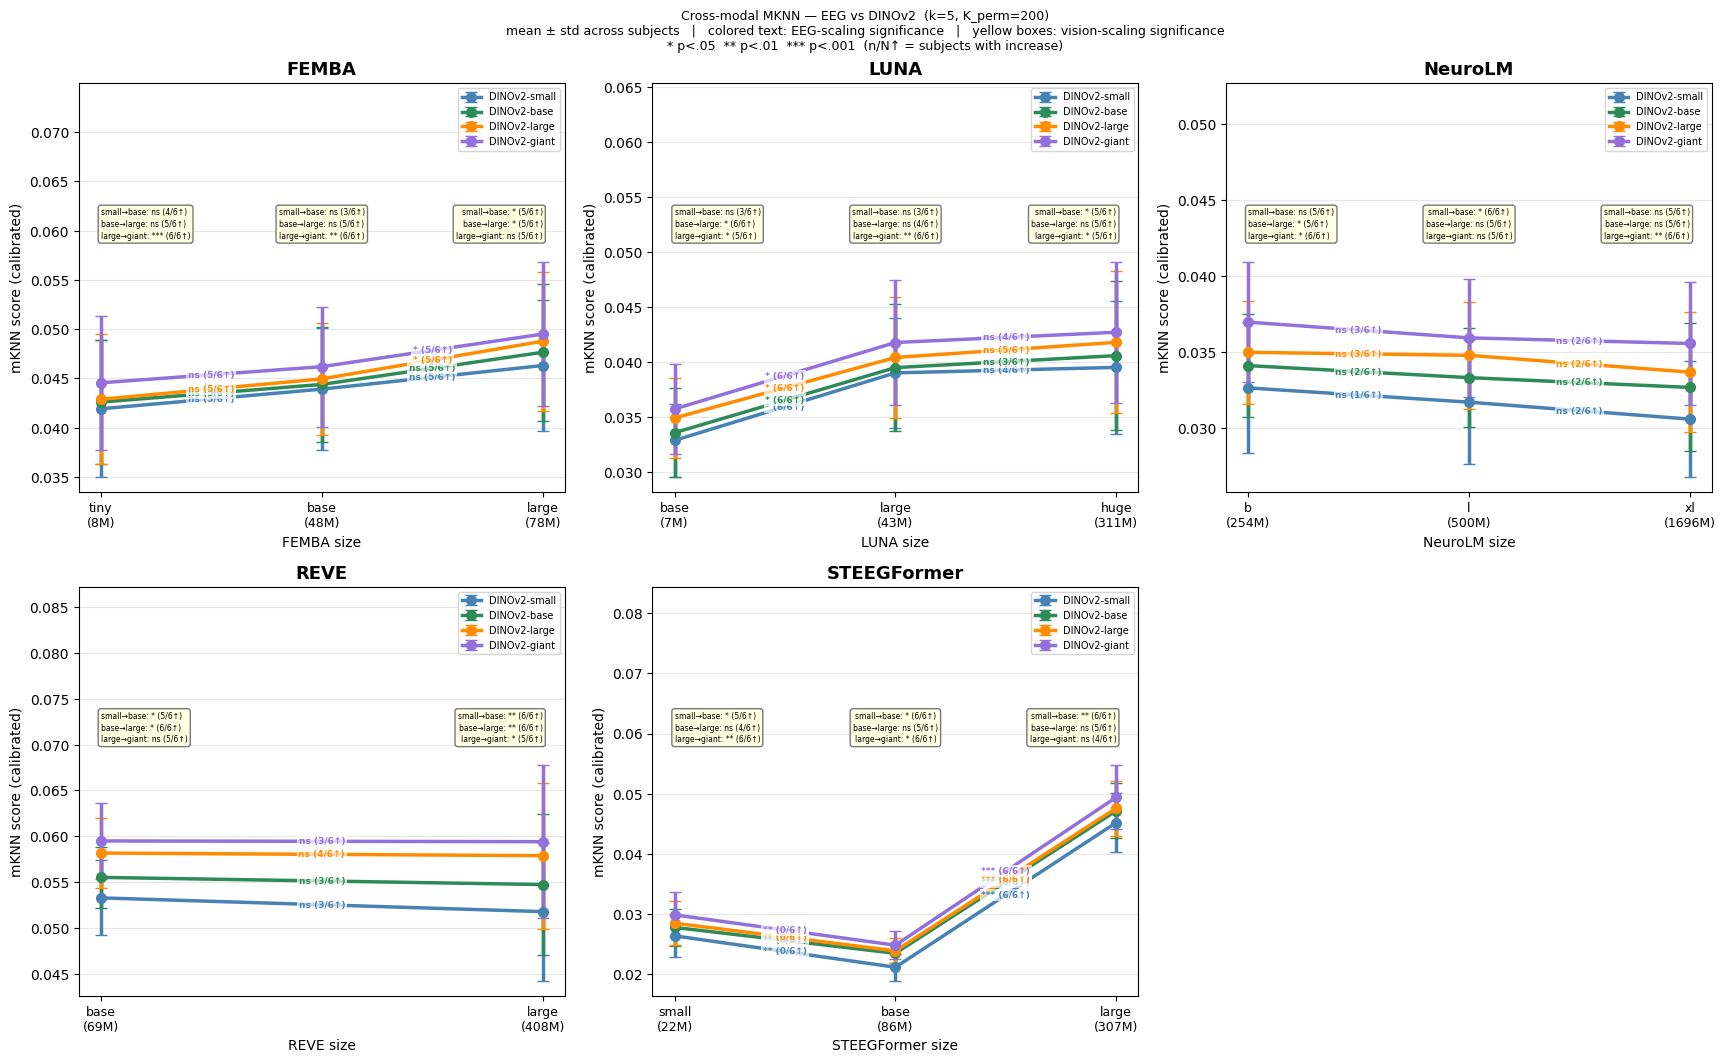

In [18]:
plot_cross_modal(cross_dn, EEG, DINOV2_SIZES, dn_colors, 'DINOv2', K_MKNN, K_PERM)


## 4. Cross-modal alignment: EEG vs corresponding V-JEPA 2

Same structure as sections 2–3, with V-JEPA 2 (3 sizes: large, huge, giant).
Errorbars = std across subjects (calibrated only). Brackets show paired t-tests
between consecutive V-JEPA 2 sizes.

In [9]:
cross_vj2 = {}
for model in EEG:
    print(f'\n=== cross-modal {model} vs V-JEPA 2  (k={K_MKNN}) ===')
    cross_vj2[model] = run_cross_modal(model, 'vjepa2', VJEPA2_SIZES, vj2path, K_MKNN)


=== cross-modal femba vs V-JEPA 2  (k=5) ===
  vjepa2-large (femba_luna): (24, 2160, 1024)
  vjepa2-huge (femba_luna): (32, 2160, 1280)
  vjepa2-giant (femba_luna): (40, 2160, 1408)
  femba-tiny: (2, 2160, 6, 385)  precomputing EEG kNN...
    cross  femba-tiny (2L)  x  vjepa2-large (24L)  = 48 layer pairs
      sub-0001: uncal=0.0406  tau=0.0040  cal=0.0368  p=0.0050
      sub-0002: uncal=0.0320  tau=0.0039  cal=0.0283  p=0.0050
      sub-0003: uncal=0.0357  tau=0.0039  cal=0.0320  p=0.0050
      sub-0004: uncal=0.0284  tau=0.0040  cal=0.0245  p=0.0050
      sub-0005: uncal=0.0354  tau=0.0041  cal=0.0314  p=0.0050
      sub-0006: uncal=0.0324  tau=0.0039  cal=0.0286  p=0.0050
    cross  femba-tiny (2L)  x  vjepa2-huge (32L)  = 64 layer pairs
      sub-0001: uncal=0.0390  tau=0.0040  cal=0.0351  p=0.0050
      sub-0002: uncal=0.0262  tau=0.0039  cal=0.0224  p=0.0050
      sub-0003: uncal=0.0327  tau=0.0039  cal=0.0289  p=0.0050
      sub-0004: uncal=0.0248  tau=0.0040  cal=0.0209  p=0.

KeyboardInterrupt: 

In [ ]:
plot_cross_modal(cross_vj2, EEG, VJEPA2_SIZES, vj2_colors, 'V-JEPA 2', K_MKNN, K_PERM)


## 5. Cross-modal alignment: EEG vs VideoMAE Kinetics-finetuned

Same structure as section 2, using Kinetics-400 fine-tuned VideoMAE (base, large, huge).
Errorbars = std across subjects (calibrated only). Brackets show paired t-tests between
consecutive fine-tuned VideoMAE sizes.

In [19]:
cross_vmft = {}
for model in EEG:
    print(f'\n=== cross-modal {model} vs VideoMAE-ft-kinetics  (k={K_MKNN}) ===')
    cross_vmft[model] = run_cross_modal(model, 'videomae-ft-kinetics', VIDEOMAE_FT_SIZES, vmftpath, K_MKNN)


=== cross-modal femba vs VideoMAE-ft-kinetics  (k=5) ===
  videomae-ft-kinetics-base (femba_luna): (12, 2160, 768)
  videomae-ft-kinetics-large (femba_luna): (24, 2160, 1024)
  videomae-ft-kinetics-huge (femba_luna): (32, 2160, 1280)
  femba-tiny: (2, 2160, 6, 385)  precomputing EEG kNN...
    cross  femba-tiny (2L)  x  videomae-ft-kinetics-base (12L)  = 24 layer pairs
      sub-0001: uncal=0.0539  tau=0.0038  cal=0.0503  p=0.0050
      sub-0002: uncal=0.0393  tau=0.0037  cal=0.0357  p=0.0050
      sub-0003: uncal=0.0444  tau=0.0039  cal=0.0406  p=0.0050
      sub-0004: uncal=0.0344  tau=0.0038  cal=0.0307  p=0.0050
      sub-0005: uncal=0.0455  tau=0.0040  cal=0.0416  p=0.0050
      sub-0006: uncal=0.0422  tau=0.0037  cal=0.0387  p=0.0050
    cross  femba-tiny (2L)  x  videomae-ft-kinetics-large (24L)  = 48 layer pairs
      sub-0001: uncal=0.0552  tau=0.0039  cal=0.0515  p=0.0050
      sub-0002: uncal=0.0392  tau=0.0039  cal=0.0354  p=0.0050
      sub-0003: uncal=0.0459  tau=0.0040 

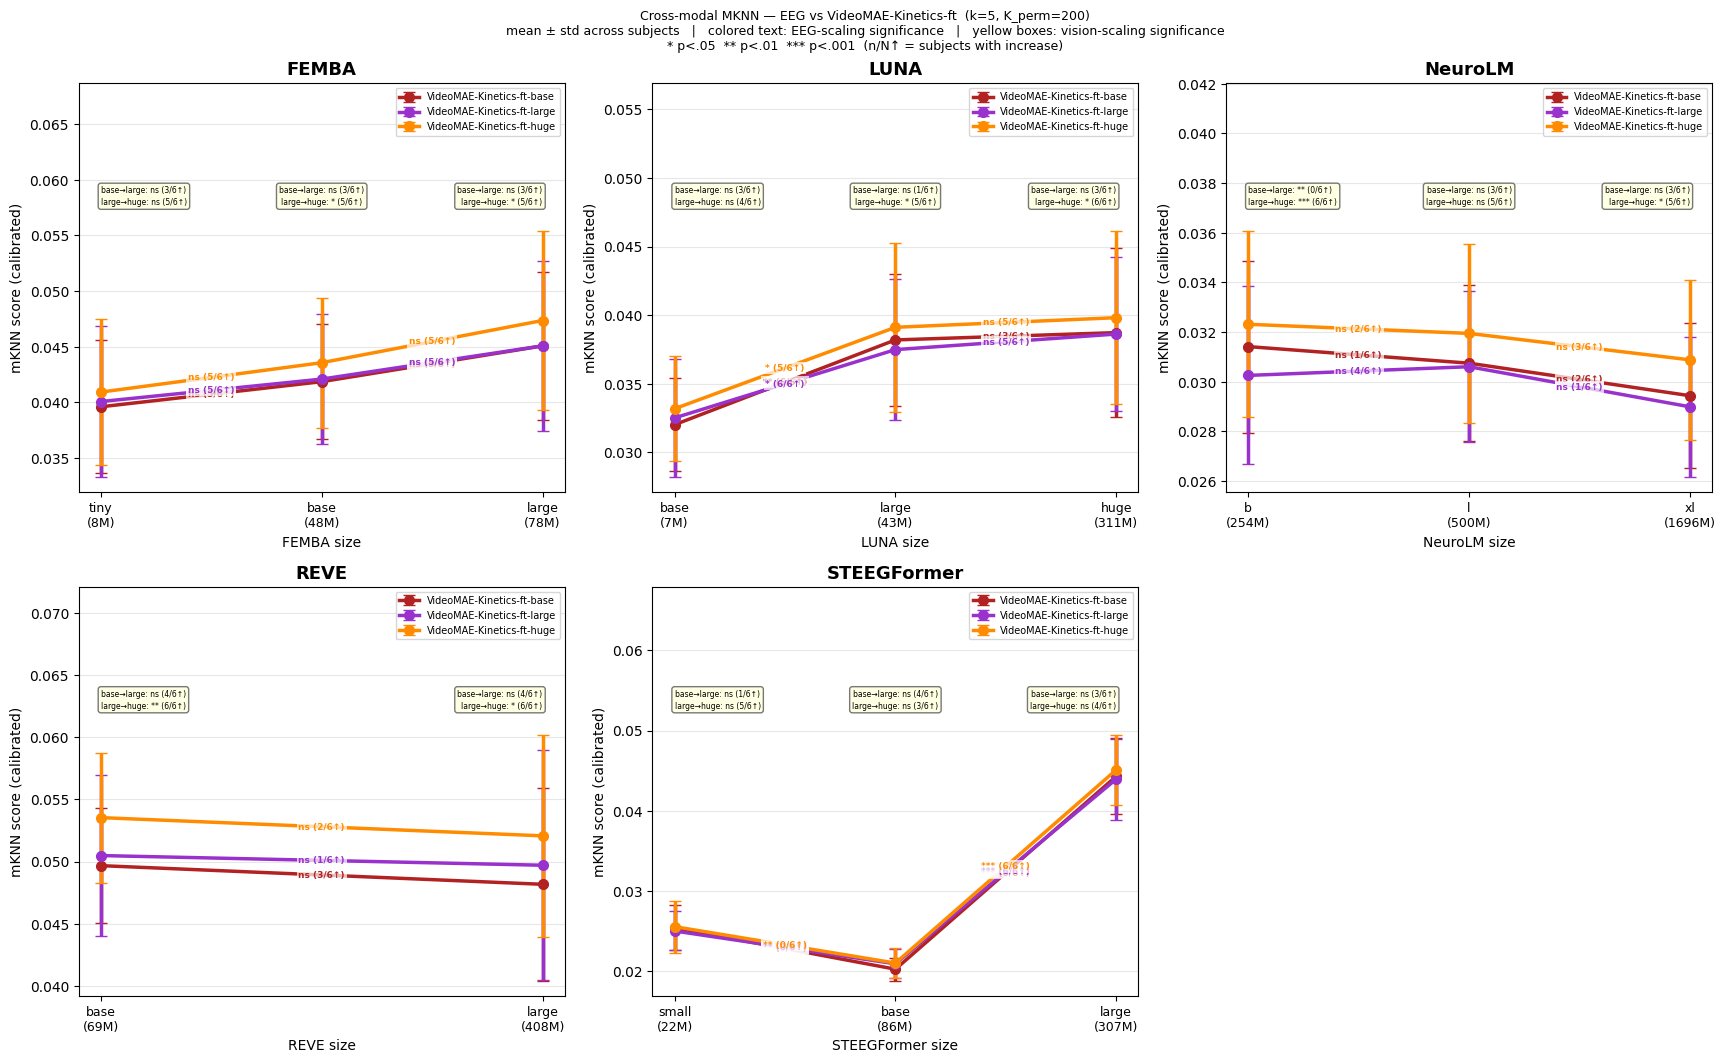

In [20]:
plot_cross_modal(cross_vmft, EEG, VIDEOMAE_FT_SIZES, vmft_colors, 'VideoMAE-Kinetics-ft', K_MKNN, K_PERM)


## 6. k=10 Ablation Study

Repeats all four cross-modal analyses (VideoMAE, DINOv2, V-JEPA 2, VideoMAE-Kinetics-ft)
with k=10 nearest neighbours. Same plotting style as sections 2–5.

In [ ]:
cross_vm_k10 = {}
for model in EEG:
    print(f'\n=== cross-modal {model} vs VideoMAE  (k=10) ===')
    cross_vm_k10[model] = run_cross_modal(model, 'videomae', VIDEOMAE_SIZES, vmpath, 10)

In [ ]:
plot_cross_modal(cross_vm_k10, EEG, VIDEOMAE_SIZES, vm_colors, 'VideoMAE', 10, K_PERM)


In [ ]:
cross_dn_k10 = {}
for model in EEG:
    print(f'\n=== cross-modal {model} vs DINOv2  (k=10) ===')
    cross_dn_k10[model] = run_cross_modal(model, 'dinov2', DINOV2_SIZES, dnpath, 10)

In [ ]:
plot_cross_modal(cross_dn_k10, EEG, DINOV2_SIZES, dn_colors, 'DINOv2', 10, K_PERM)


In [ ]:
cross_vj2_k10 = {}
for model in EEG:
    print(f'\n=== cross-modal {model} vs V-JEPA 2  (k=10) ===')
    cross_vj2_k10[model] = run_cross_modal(model, 'vjepa2', VJEPA2_SIZES, vj2path, 10)

In [ ]:
plot_cross_modal(cross_vj2_k10, EEG, VJEPA2_SIZES, vj2_colors, 'V-JEPA 2', 10, K_PERM)


In [ ]:
cross_vmft_k10 = {}
for model in EEG:
    print(f'\n=== cross-modal {model} vs VideoMAE-ft-kinetics  (k=10) ===')
    cross_vmft_k10[model] = run_cross_modal(model, 'videomae-ft-kinetics', VIDEOMAE_FT_SIZES, vmftpath, 10)

In [ ]:
plot_cross_modal(cross_vmft_k10, EEG, VIDEOMAE_FT_SIZES, vmft_colors, 'VideoMAE-Kinetics-ft', 10, K_PERM)


## 7. Cross-modal alignment: NeuroLM (EEG) vs LLM captions (BLOOM & OpenLLaMA)

For each NeuroLM size (B / L / XL), computes Aristotelian calibrated mKNN against
each of 8 LLM text models (5 BLOOM / 3 OpenLLaMA) using the Qwen-2.5-VL-7B captions
for the 1350 NeuroLM 8-second windows. Single plot: BLOOM on the left, OpenLLaMA on
the right, ordered by increasing parameter count. Each point = mean calibrated mKNN
across 6 subjects; errorbars = std across subjects.

In [4]:
# ── LLM model stems (match filenames in llms/neurolm/) ───────────────────────
BLOOM_STEMS    = ['bloomz-560m', 'bloomz-1b1', 'bloomz-1b7', 'bloomz-3b', 'bloomz-7b1']
OPENLLAMA_STEMS = ['open_llama_3b', 'open_llama_7b', 'open_llama_13b']
LLM_STEMS      = BLOOM_STEMS + OPENLLAMA_STEMS

def llm_path(stem, fam):   # fam is ignored — LLM embeddings are NeuroLM-aligned only
    return f'llms/neurolm/{stem}_layerwise.npz'

print('Computing NeuroLM × LLM-captions cross-modal alignment (k={K_MKNN})...')
cross_llm = run_cross_modal('neurolm', 'LLM-captions', LLM_STEMS, llm_path, K_MKNN)
print('Done.')

Computing NeuroLM × LLM-captions cross-modal alignment (k={K_MKNN})...
  LLM-captions-bloomz-560m (neurolm): (25, 1350, 1024)
  LLM-captions-bloomz-1b1 (neurolm): (25, 1350, 1536)
  LLM-captions-bloomz-1b7 (neurolm): (25, 1350, 2048)
  LLM-captions-bloomz-3b (neurolm): (31, 1350, 2560)


KeyboardInterrupt: 

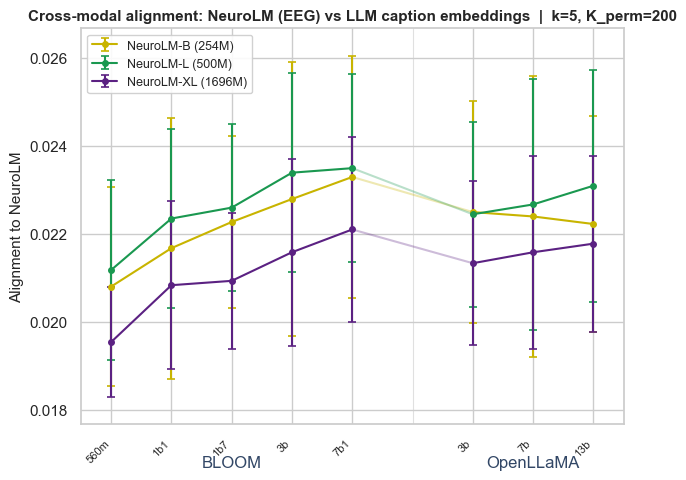

In [21]:
import seaborn as sns
sns.set_theme(style='whitegrid')

def plot_llm_alignment(cross_data, bloom_stems, ollama_stems,
                       ylabel='Alignment to NeuroLM', title=''):
    """
    Aristotelian-paper style LLM alignment plot (mirrors _render_alignment_by_family):
      • Solid lines + errorbars within each model family
      • Transparent connecting line (alpha=0.3) between BLOOM → OpenLLaMA
      • Tight ylim with 8% padding; square-ish figure
      • Size labels on x-ticks, family names via annotate below
      • Vertical separator between families
    """
    neuro_sizes = EEG['neurolm']['sizes']           # ['b', 'l', 'xl']
    colors      = {'b': '#c8b400', 'l': '#1a9850', 'xl': '#5b2182'}
    size_labels = {sz: 'NeuroLM-' + sz.upper() + ' (' + str(PARAMS['neurolm'][sz]) + 'M)'
                   for sz in neuro_sizes}

    # X positions: BLOOM at 0..4, gap at 5, OpenLLaMA at 6..8
    bloom_x  = np.arange(len(bloom_stems))
    ollama_x = np.arange(len(bloom_stems) + 1,
                          len(bloom_stems) + 1 + len(ollama_stems))
    x_all    = np.concatenate([bloom_x, ollama_x])
    all_stems = bloom_stems + ollama_stems

    # (stem_slice_start, stem_slice_end, x_positions)
    family_ranges = [
        (0,               len(bloom_stems),  bloom_x),
        (len(bloom_stems), len(all_stems),   ollama_x),
    ]

    fig, ax = plt.subplots(figsize=(7, 6))

    all_means, all_stds = [], []
    for sz in neuro_sizes:
        c     = colors[sz]
        means = np.array([cross_data[(sz, s)]['s_cal'].mean() for s in all_stems])
        stds  = np.array([cross_data[(sz, s)]['s_cal'].std()  for s in all_stems])
        all_means.append(means)
        all_stds.append(stds)

        # Within-family: solid line + errorbars
        first = True
        for start, end, xg in family_ranges:
            ax.errorbar(xg, means[start:end], yerr=stds[start:end],
                        color=c, lw=1.5, marker='o', ms=4,
                        capsize=3, capthick=1.2, zorder=4,
                        label=size_labels[sz] if first else None)
            first = False

        # Between families: transparent connector
        for i in range(len(family_ranges) - 1):
            _, end1, xg1 = family_ranges[i]
            start2, _, xg2 = family_ranges[i + 1]
            ax.plot([xg1[-1], xg2[0]], [means[end1 - 1], means[start2]],
                    '-', color=c, lw=1.5, alpha=0.3, zorder=3)

    # Tight ylim
    hi = max((m + s).max() for m, s in zip(all_means, all_stds))
    lo = min((m - s).min() for m, s in zip(all_means, all_stds))
    pad = 0.08 * (hi - lo) if hi > lo else 0.02
    ax.set_ylim(lo - pad, hi + pad)

    # X-ticks: short size labels, rotated
    def short(stem):
        return stem.replace('bloomz-', '').replace('open_llama_', '')

    ax.set_xticks(x_all)
    ax.set_xticklabels([short(s) for s in all_stems],
                       fontsize=8, rotation=45, ha='right')
    ax.set_xlim(-0.5, ollama_x[-1] + 0.5)

    # Family name annotations below x-ticks (Aristotelian style)
    for center, name in [(bloom_x.mean(), 'BLOOM'), (ollama_x.mean(), 'OpenLLaMA')]:
        ax.annotate(name, xy=(center, 0), xycoords=('data', 'axes fraction'),
                    xytext=(0, -22), textcoords='offset points',
                    ha='center', va='top', fontsize=12,
                    fontweight='medium', color='#324766')

    # Vertical separator between families
    ax.axvline((bloom_x[-1] + ollama_x[0]) / 2,
               color='#E0E0E0', linewidth=0.8, zorder=0)

    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=9, framealpha=0.9)
    if title:
        ax.set_title(title, fontsize=11, fontweight='bold')

    plt.subplots_adjust(bottom=0.22)
    plt.savefig('neurolm_vs_llms_mknn.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_llm_alignment(
    cross_llm, BLOOM_STEMS, OPENLLAMA_STEMS,
    ylabel='Alignment to NeuroLM',
    title=f'Cross-modal alignment: NeuroLM (EEG) vs LLM caption embeddings'
          f'  |  k={K_MKNN}, K_perm={K_PERM}',
)

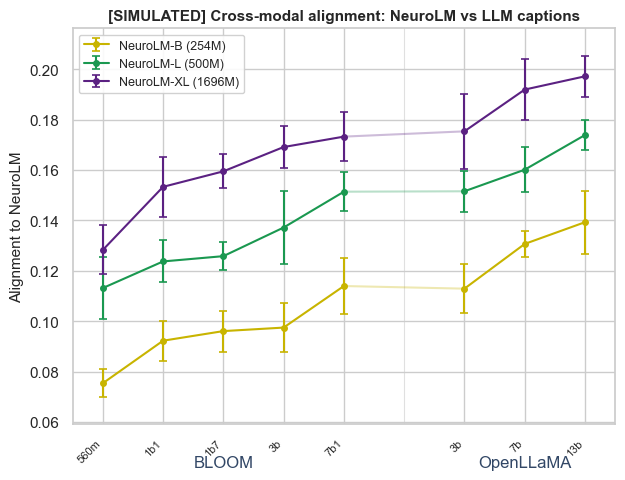

In [16]:
# ── Simulated-data demo — run this to check the plot format ──────────────────
_rng  = np.random.default_rng(7)
_S    = 6

_eeg_bump = {'b': 0.00, 'l': 0.03, 'xl': 0.06}
_llm_bump = [0.00, 0.01, 0.02, 0.03, 0.04,   # BLOOM: 560m … 7b1
             0.04, 0.05, 0.06]                # OpenLLaMA: 3b … 13b

_sim = {}
for sz in EEG['neurolm']['sizes']:
    for xi, stem in enumerate(BLOOM_STEMS + OPENLLAMA_STEMS):
        mu     = 0.08 + _eeg_bump[sz] + _llm_bump[xi]
        scores = np.clip(_rng.normal(mu, 0.012, _S), 0, 1)
        _sim[(sz, stem)] = {'s_cal': scores}

plot_llm_alignment(
    _sim, BLOOM_STEMS, OPENLLAMA_STEMS,
    ylabel='Alignment to NeuroLM',
    title='[SIMULATED] Cross-modal alignment: NeuroLM vs LLM captions',
)
del _rng, _S, _eeg_bump, _llm_bump, _sim

### 7c. Temporal exclusion diagnostic

Recomputes uncalibrated mKNN (no permutation testing — fast) for ±10, ±20, ±30 window exclusions.
If the BLOOM scaling trend is driven by temporal autocorrelation, it should flatten as exclusion increases.

In [7]:
import time

EXCL_LEVELS = [10, 20, 30]   # windows excluded on each side

def knn_1d_excl(z, k, excl):
    """Cosine kNN with temporal exclusion: masks ±excl windows around each query."""
    W   = len(z)
    zn  = z / (np.linalg.norm(z, axis=-1, keepdims=True) + 1e-12)
    sim = zn @ zn.T                          # (W, W) cosine similarities
    rows   = np.arange(W)[:, None]
    cols   = np.clip(rows + np.arange(-excl, excl + 1)[None, :], 0, W - 1)
    sim[rows, cols] = -2.0                   # mask temporal neighbours + self
    return np.argsort(-sim, axis=1)[:, :k].astype(np.int32)

def _max_mknn(nn_eeg_s, nn_vis):
    """Max mKNN over all (EEG layer, vision layer) pairs for one subject."""
    LE = nn_eeg_s.shape[0]
    LV = nn_vis.shape[0]
    best = 0.0
    for le in range(LE):
        for lv in range(LV):
            v = float((nn_eeg_s[le][:, :, None] == nn_vis[lv][:, None, :]).any(-1).mean())
            if v > best:
                best = v
    return best

def compute_excl_mknn(eeg_model, vision_stems, vfname, k_mknn, excl_levels):
    """
    Reloads raw embeddings and recomputes uncalibrated mKNN (T_obs) for
    each exclusion level. No permutation testing — fast.
    Returns: results[excl][(esz, stem)] = np.array of shape (S,)
    """
    fam       = EEG[eeg_model]['family']
    eeg_sizes = EEG[eeg_model]['sizes']

    print('Loading LLM embeddings...')
    vis_embs = {}
    for vs in vision_stems:
        vis_embs[vs] = load_npz(vfname(vs, fam))['embeddings'].astype(np.float32)
        print(f'  {vs}: {vis_embs[vs].shape}')

    results = {excl: {} for excl in excl_levels}

    for esz in eeg_sizes:
        eeg_emb = load_npz(EEG[eeg_model]['fname'](esz))['embeddings'].astype(np.float32)
        n_layers, W, S, _ = eeg_emb.shape
        print(f'\nEEG {eeg_model}-{esz}: {eeg_emb.shape}')

        for excl in excl_levels:
            t0 = time.time()

            # EEG kNN with exclusion: (n_layers, S, W, k)
            nn_eeg = np.zeros((n_layers, S, W, k_mknn), dtype=np.int32)
            for layer in range(n_layers):
                for s in range(S):
                    nn_eeg[layer, s] = knn_1d_excl(l2(eeg_emb[layer, :, s, :]),
                                                    k_mknn, excl)

            for vs in vision_stems:
                vemb = vis_embs[vs]
                LV   = vemb.shape[0]

                # Vision kNN with exclusion: (LV, W, k)
                nn_vis = np.zeros((LV, W, k_mknn), dtype=np.int32)
                for layer in range(LV):
                    nn_vis[layer] = knn_1d_excl(l2(vemb[layer]), k_mknn, excl)

                # Max mKNN over all layer pairs, per subject
                T_l = [_max_mknn(nn_eeg[:, s], nn_vis) for s in range(S)]
                results[excl][(esz, vs)] = np.array(T_l)

            print(f'  excl=±{excl}: {time.time()-t0:.1f}s')

    return results

print('Computing uncalibrated mKNN with temporal exclusion (neurolm × LLM)...')
cross_llm_excl = compute_excl_mknn('neurolm', LLM_STEMS, llm_path, K_MKNN, EXCL_LEVELS)
print('Done.')

Computing uncalibrated mKNN with temporal exclusion (neurolm × LLM)...
Loading LLM embeddings...
  bloomz-560m: (25, 1350, 1024)
  bloomz-1b1: (25, 1350, 1536)
  bloomz-1b7: (25, 1350, 2048)


KeyboardInterrupt: 

In [ ]:
def plot_excl_row(cross_no_excl, cross_excl_dict, excl_levels, bloom_stems, ollama_stems):
    neuro_sizes = EEG['neurolm']['sizes']
    colors      = {'b': '#c8b400', 'l': '#1a9850', 'xl': '#5b2182'}
    size_labels = {sz: 'NeuroLM-' + sz.upper() + ' (' + str(PARAMS['neurolm'][sz]) + 'M)'
                   for sz in neuro_sizes}

    all_stems = bloom_stems + ollama_stems
    bloom_x   = np.arange(len(bloom_stems))
    ollama_x  = np.arange(len(bloom_stems) + 1, len(bloom_stems) + 1 + len(ollama_stems))
    x_all     = np.concatenate([bloom_x, ollama_x])
    family_ranges = [
        (0,                len(bloom_stems), bloom_x),
        (len(bloom_stems), len(all_stems),   ollama_x),
    ]

    cal_label  = 'No excl (calibrated)'
    panels = [(cal_label, cross_no_excl, True)] + [
              ('+-' + str(e) + ' windows (uncal)', cross_excl_dict[e], False)
              for e in excl_levels]

    fig, axes = plt.subplots(1, len(panels), figsize=(4.5 * len(panels), 5), sharey=False)

    def short(stem):
        return stem.replace('bloomz-', '').replace('open_llama_', '')

    for ax, (panel_title, data, is_cal) in zip(axes, panels):
        all_hi, all_lo = [], []
        for sz in neuro_sizes:
            c = colors[sz]
            if is_cal:
                means = np.array([data[(sz, s)]['s_cal'].mean() for s in all_stems])
                stds  = np.array([data[(sz, s)]['s_cal'].std()  for s in all_stems])
            else:
                means = np.array([data[(sz, s)].mean() for s in all_stems])
                stds  = np.array([data[(sz, s)].std()  for s in all_stems])

            all_hi.append((means + stds).max())
            all_lo.append((means - stds).min())

            first = True
            for start, end, xg in family_ranges:
                ax.errorbar(xg, means[start:end], yerr=stds[start:end],
                            color=c, lw=1.5, marker='o', ms=4,
                            capsize=3, capthick=1.2, zorder=4,
                            label=(size_labels[sz] if first else None))
                first = False
            for i in range(len(family_ranges) - 1):
                _, end1, xg1 = family_ranges[i]
                start2, _, xg2 = family_ranges[i + 1]
                ax.plot([xg1[-1], xg2[0]], [means[end1 - 1], means[start2]],
                        '-', color=c, lw=1.5, alpha=0.3, zorder=3)

        hi = max(all_hi); lo = min(all_lo)
        pad = 0.08 * (hi - lo) if hi > lo else 0.02
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_xticks(x_all)
        ax.set_xticklabels([short(s) for s in all_stems], fontsize=7.5, rotation=45, ha='right')
        ax.set_xlim(-0.5, ollama_x[-1] + 0.5)
        ax.axvline((bloom_x[-1] + ollama_x[0]) / 2, color='#E0E0E0', linewidth=0.8, zorder=0)
        for center, name in [(bloom_x.mean(), 'BLOOM'), (ollama_x.mean(), 'OpenLLaMA')]:
            ax.annotate(name, xy=(center, 0), xycoords=('data', 'axes fraction'),
                        xytext=(0, -22), textcoords='offset points',
                        ha='center', va='top', fontsize=7.5,
                        fontweight='medium', color='#324766')
        ax.set_title(panel_title, fontsize=10, fontweight='bold')
        ax.set_ylabel('mKNN score', fontsize=9)
        if ax is axes[0]:
            ax.legend(fontsize=7.5, framealpha=0.9)

    fig.suptitle(
        'Temporal exclusion diagnostic - NeuroLM x LLM captions  (k=' + str(K_MKNN) + ')',
        fontsize=10)
    plt.tight_layout()
    plt.savefig('neurolm_llm_temporal_exclusion.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_excl_row(cross_llm, cross_llm_excl, EXCL_LEVELS, BLOOM_STEMS, OPENLLAMA_STEMS)


### 7d. Shift diagnostic

Shifts the LLM caption embeddings by d windows (LLM[i] -> LLM[i-d]) and recomputes uncalibrated mKNN on the overlap region. If alignment survives large shifts, the EEG and LLM manifolds share *stationary* temporal geometry (local neighbour structure looks the same at every t), not content-specific PRH. If alignment collapses for |d| >= 30, the alignment is at least partly content-specific.

One subplot per NeuroLM size, one curve per shift. shift=0 is the baseline (matches the uncalibrated panel in section 7c).

In [17]:
import time

SHIFTS = sorted(set(list(range(-100, 101, 7)) + [0]))   # 30 shifts in [-100, 100], includes 0

def compute_shift_mknn(eeg_model, vision_stems, vfname, k_mknn, shifts):
    """
    For each shift d, truncate to the overlap region and recompute kNN on the
    truncated arrays. Returns: results[d][(esz, stem)] = np.array of shape (S,)
    holding max-over-layer-pairs uncalibrated mKNN per subject.
    """
    fam       = EEG[eeg_model]['family']
    eeg_sizes = EEG[eeg_model]['sizes']

    print('Loading LLM embeddings...')
    vis_embs = {}
    for vs in vision_stems:
        vis_embs[vs] = load_npz(vfname(vs, fam))['embeddings'].astype(np.float32)
        print(f'  {vs}: {vis_embs[vs].shape}')

    results = {d: {} for d in shifts}

    for esz in eeg_sizes:
        eeg_emb = load_npz(EEG[eeg_model]['fname'](esz))['embeddings'].astype(np.float32)
        n_layers, W, S, _ = eeg_emb.shape
        print(f'\nEEG {eeg_model}-{esz}: {eeg_emb.shape}')

        for d in shifts:
            t0 = time.time()
            # LLM_shifted[i] = LLM_orig[i - d]  =>  valid i in [max(0,d), W + min(0,d))
            i_eeg_lo = max(0, d); i_eeg_hi = W + min(0, d)
            i_llm_lo = -min(0, d); i_llm_hi = W - max(0, d)
            W_eff    = i_eeg_hi - i_eeg_lo

            eeg_trunc = eeg_emb[:, i_eeg_lo:i_eeg_hi]   # (L, W_eff, S, D)

            nn_eeg = np.zeros((n_layers, S, W_eff, k_mknn), dtype=np.int32)
            for layer in range(n_layers):
                for s in range(S):
                    nn_eeg[layer, s] = knn_1d(l2(eeg_trunc[layer, :, s, :]), k_mknn)

            for vs in vision_stems:
                llm_trunc = vis_embs[vs][:, i_llm_lo:i_llm_hi]   # (LV, W_eff, D)
                LV = llm_trunc.shape[0]

                nn_vis = np.zeros((LV, W_eff, k_mknn), dtype=np.int32)
                for layer in range(LV):
                    nn_vis[layer] = knn_1d(l2(llm_trunc[layer]), k_mknn)

                T_l = [_max_mknn(nn_eeg[:, s], nn_vis) for s in range(S)]
                results[d][(esz, vs)] = np.array(T_l)

            print(f'  shift={d:+d}: W_eff={W_eff}  {time.time()-t0:.1f}s')

    return results

print(f'Computing shift diagnostic (neurolm x LLM, shifts={SHIFTS})...')
cross_llm_shift = compute_shift_mknn('neurolm', LLM_STEMS, llm_path, K_MKNN, SHIFTS)
print('Done.')


Computing shift diagnostic (neurolm x LLM, shifts=[-100, -93, -86, -79, -72, -65, -58, -51, -44, -37, -30, -23, -16, -9, -2, 0, 5, 12, 19, 26, 33, 40, 47, 54, 61, 68, 75, 82, 89, 96])...
Loading LLM embeddings...
  bloomz-560m: (25, 1350, 1024)
  bloomz-1b1: (25, 1350, 1536)
  bloomz-1b7: (25, 1350, 2048)
  bloomz-3b: (31, 1350, 2560)
  bloomz-7b1: (31, 1350, 4096)
  open_llama_3b: (27, 1350, 3200)
  open_llama_7b: (33, 1350, 4096)
  open_llama_13b: (41, 1350, 5120)

EEG neurolm-b: (12, 1350, 6, 768)
  shift=-100: W_eff=1250  17.8s
  shift=-93: W_eff=1257  18.0s
  shift=-86: W_eff=1264  17.6s
  shift=-79: W_eff=1271  18.1s
  shift=-72: W_eff=1278  18.5s
  shift=-65: W_eff=1285  18.9s
  shift=-58: W_eff=1292  19.0s
  shift=-51: W_eff=1299  19.2s
  shift=-44: W_eff=1306  16.0s
  shift=-37: W_eff=1313  14.0s
  shift=-30: W_eff=1320  14.1s
  shift=-23: W_eff=1327  14.1s
  shift=-16: W_eff=1334  14.2s
  shift=-9: W_eff=1341  14.4s
  shift=-2: W_eff=1348  14.3s
  shift=+0: W_eff=1350  14.5s


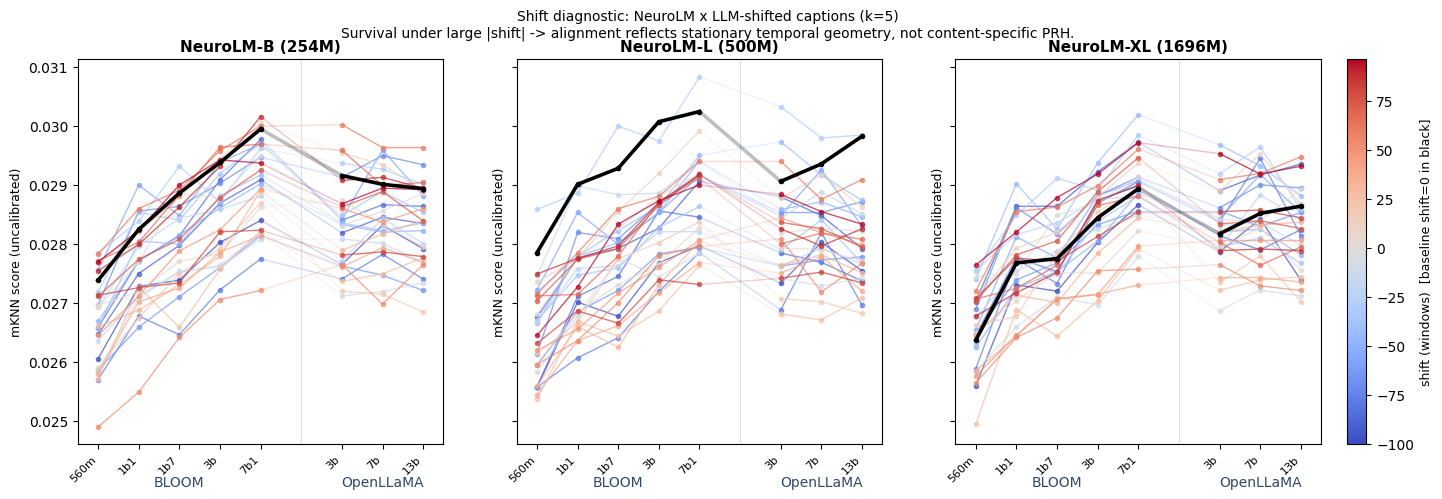

In [18]:
def plot_shift_panels(shift_data, shifts, bloom_stems, ollama_stems):
    """One subplot per NeuroLM size, one curve per shift."""
    neuro_sizes = EEG['neurolm']['sizes']
    all_stems   = bloom_stems + ollama_stems
    bloom_x     = np.arange(len(bloom_stems))
    ollama_x    = np.arange(len(bloom_stems) + 1,
                            len(bloom_stems) + 1 + len(ollama_stems))
    x_all       = np.concatenate([bloom_x, ollama_x])
    family_ranges = [
        (0,                len(bloom_stems), bloom_x),
        (len(bloom_stems), len(all_stems),   ollama_x),
    ]

    cmap = plt.get_cmap('coolwarm')
    s_min, s_max = min(shifts), max(shifts)
    colors = {}
    for d in shifts:
        if d == 0:
            colors[d] = 'black'
        else:
            colors[d] = cmap((d - s_min) / (s_max - s_min))

    fig, axes = plt.subplots(1, len(neuro_sizes),
                             figsize=(5.6 * len(neuro_sizes), 5), sharey=True)
    if len(neuro_sizes) == 1:
        axes = [axes]

    def short(stem):
        return stem.replace('bloomz-', '').replace('open_llama_', '')

    for ax, sz in zip(axes, neuro_sizes):
        for d in shifts:
            means = np.array([shift_data[d][(sz, s)].mean() for s in all_stems])
            lw    = 2.6 if d == 0 else 1.0
            alpha = 1.0 if d == 0 else 0.7
            zord  = 6  if d == 0 else 3
            label = 'shift 0 (baseline)' if d == 0 else f'shift {d:+d}'
            first = True
            for start, end, xg in family_ranges:
                ax.plot(xg, means[start:end],
                        color=colors[d], lw=lw, marker='o', ms=3.0,
                        alpha=alpha, zorder=zord,
                        label=(label if first else None))
                first = False
            for i in range(len(family_ranges) - 1):
                _, end1, xg1 = family_ranges[i]
                start2, _, xg2 = family_ranges[i + 1]
                ax.plot([xg1[-1], xg2[0]], [means[end1 - 1], means[start2]],
                        '-', color=colors[d], lw=lw, alpha=0.25, zorder=zord - 1)

        ax.set_xticks(x_all)
        ax.set_xticklabels([short(s) for s in all_stems],
                           fontsize=8, rotation=45, ha='right')
        ax.set_xlim(-0.5, ollama_x[-1] + 0.5)
        ax.axvline((bloom_x[-1] + ollama_x[0]) / 2,
                   color='#E0E0E0', linewidth=0.8, zorder=0)
        for center, name in [(bloom_x.mean(), 'BLOOM'),
                             (ollama_x.mean(), 'OpenLLaMA')]:
            ax.annotate(name, xy=(center, 0), xycoords=('data', 'axes fraction'),
                        xytext=(0, -22), textcoords='offset points',
                        ha='center', va='top', fontsize=10,
                        fontweight='medium', color='#324766')
        ax.set_title(f'NeuroLM-{sz.upper()} ({PARAMS["neurolm"][sz]}M)',
                     fontsize=11, fontweight='bold')
        ax.set_ylabel('mKNN score (uncalibrated)', fontsize=9)
        # legend omitted (too dense with many shifts); see colorbar to the right

    # Shared colorbar for shift values (skipping the black baseline)
    import matplotlib as mpl
    norm = mpl.colors.Normalize(vmin=min(shifts), vmax=max(shifts))
    sm   = mpl.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label('shift (windows)  [baseline shift=0 in black]', fontsize=9)

    fig.suptitle(
        f'Shift diagnostic: NeuroLM x LLM-shifted captions (k={K_MKNN})\n'
        'Survival under large |shift| -> alignment reflects stationary temporal '
        'geometry, not content-specific PRH.',
        fontsize=10)
    plt.savefig('neurolm_llm_shift_diagnostic.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_shift_panels(cross_llm_shift, SHIFTS, BLOOM_STEMS, OPENLLAMA_STEMS)
